# d 계속 누르면서 어노테이션 잘 됐는지 체크

In [ ]:
import os
import cv2
import numpy as np

# --- 설정값 ---
DATASET_FOLDER = "track_dataset"
Y_RATIO = 4 / 5
DOT_COLOR = (255, 0, 0)
LINE_COLOR = (0, 255, 0)
DOT_RADIUS = 7
TEXT_COLOR = (255, 255, 255)

# --- 프로그램 시작 ---

# 1. [수정된 부분] 주피터 노트북의 현재 실행 경로를 기준으로 폴더 찾기
try:
    # .py 파일의 __file__ 대신 os.getcwd() 사용
    current_path = os.getcwd()
    dataset_path = os.path.join(current_path, DATASET_FOLDER)

    print(f"'{dataset_path}' 에서 이미지 스캔 및 필터링 중...")

    valid_image_files = []
    for filename in os.listdir(dataset_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                int(filename.split('_')[0])
                valid_image_files.append(filename)
            except (ValueError, IndexError):
                print(f"  -> 정보: '{filename}'은 형식이 달라 건너뜁니다.")
                continue

    valid_image_files.sort(key=lambda f: int(f.split('_')[0]))

    if not valid_image_files:
        print(f"오류: '{DATASET_FOLDER}' 폴더에 유효한 이미지 파일이 없습니다.")
    else:
        # 이미지 인덱스 초기화
        current_index = 0

        print("\n--- 조작법 ---")
        print(" d : 다음 이미지")
        print(" a : 이전 이미지")
        print(" q : 종료 (창을 선택한 상태에서 누르세요)")
        print("---------------")

        # 메인 루프
        while True:
            filename = valid_image_files[current_index]
            file_path = os.path.join(dataset_path, filename)
            image = cv2.imread(file_path)

            if image is None:
                print(f"경고: '{filename}' 파일을 불러올 수 없습니다.")
                current_index = (current_index + 1) % len(valid_image_files)
                continue

            height, width, _ = image.shape
            x_value_raw = int(filename.split('_')[0])
            x_value = max(0, min(x_value_raw, 300))

            y_pos = int(height * Y_RATIO)
            x_pos = int((x_value / 300.0) * width)
            display_image = image.copy()
            cv2.line(display_image, (0, y_pos), (width, y_pos), LINE_COLOR, 1)
            cv2.circle(display_image, (x_pos, y_pos), DOT_RADIUS, DOT_COLOR, -1)

            info_text = f"File: {filename} ({current_index + 1}/{len(valid_image_files)}) | Value: {x_value_raw} -> {x_value}"
            cv2.putText(display_image, info_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2, cv2.LINE_AA)
            cv2.imshow("Annotation Viewer v1.1 (ipynb)", display_image)

            key = cv2.waitKey(1) # [수정] 0 대신 1을 주어 노트북 환경에서 더 안정적으로 반응하게 함

            if key == ord('d'):
                current_index = (current_index + 1) % len(valid_image_files)
            elif key == ord('a'):
                current_index = (current_index - 1 + len(valid_image_files)) % len(valid_image_files)
            elif key == ord('q') or key == 27:
                break

        # 루프가 끝나면 창을 닫음
        cv2.destroyAllWindows()
        # 일부 환경에서 창이 바로 안 닫히는 경우를 방지하기 위해 추가
        for i in range(5):
            cv2.waitKey(1)
        print("\n프로그램을 종료합니다.")

except FileNotFoundError:
    print(f"오류: '{DATASET_FOLDER}' 폴더를 찾을 수 없습니다.")
    print("노트북 파일(.ipynb)과 같은 위치에 폴더를 만들어주세요.")

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset' 에서 이미지 스캔 및 필터링 중...

--- 조작법 ---
 d : 다음 이미지
 a : 이전 이미지
 q : 종료 (창을 선택한 상태에서 누르세요)
---------------

프로그램을 종료합니다.


# 나만의 어노테이션. 첫 번째 숫자와 두 번재 숫자가 무조건 같다.


In [ ]:
import os
import cv2
import numpy as np
import shutil

# --- 설정값 ---
DATASET_FOLDER = "track_dataset"
PROCESSED_FOLDER = "annotated"
# [추가] 삭제(격리)할 이미지를 옮길 폴더 이름
DROPPED_FOLDER_NAME = "dropped_images"

Y_RATIO = 4 / 5
DOT_COLOR = (255, 0, 0)
LINE_COLOR = (0, 255, 0)
DOT_RADIUS = 7
TEXT_COLOR = (0, 255, 255)

# --- 전역 변수 ---
temp_steering_value = None

# --- 마우스 콜백 함수 ---
def mouse_callback(event, x, y, flags, param):
    global temp_steering_value
    if event == cv2.EVENT_LBUTTONDOWN:
        image_width = param
        clicked_value = int((x / image_width) * 300.0)
        temp_steering_value = max(0, min(clicked_value, 300))

# --- 메인 프로그램 로직 ---
def run_annotator_v2_2():
    global temp_steering_value

    try:
        current_path = os.getcwd()
        dataset_path = os.path.join(current_path, DATASET_FOLDER)
        processed_path = os.path.join(dataset_path, PROCESSED_FOLDER)
        # [추가] dropped_images 폴더 경로 설정 및 생성
        dropped_path = os.path.join(dataset_path, DROPPED_FOLDER_NAME)

        os.makedirs(processed_path, exist_ok=True)
        os.makedirs(dropped_path, exist_ok=True) # 추가

        print(f"'{dataset_path}' 에서 이미지 스캔 및 필터링 중...")
        valid_image_files = []
        for filename in os.listdir(dataset_path):
            full_path_check = os.path.join(dataset_path, filename)
            if os.path.isfile(full_path_check) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    int(filename.split('_')[0])
                    valid_image_files.append(filename)
                except (ValueError, IndexError):
                    continue

        valid_image_files.sort(key=lambda f: int(f.split('_')[0]))

        if not valid_image_files:
            print(f"오류: '{DATASET_FOLDER}' 폴더에 수정할 이미지 파일이 없습니다.")
            return

    except FileNotFoundError:
        print(f"오류: '{DATASET_FOLDER}' 폴더를 찾을 수 없습니다.")
        return

    current_index = 0
    window_name = "Annotation Tool v2.2 (Real-time)"
    cv2.namedWindow(window_name)

    print("\n--- 조작법 ---")
    print(" 마우스 좌클릭 : 조향값 위치 실시간 수정")
    print(" s : 현재 값으로 저장하고 다음 이미지로")
    print(" x : 현재 이미지 삭제(격리)하고 다음으로") # [추가]
    print(" d : 저장하지 않고 다음 이미지로")
    print(" a : 이전 이미지로")
    print(" q / ESC : 종료")
    print("---------------")

    quit_app = False
    while not quit_app:
        if not (0 <= current_index < len(valid_image_files)):
            print("모든 파일을 처리했거나, 남은 파일이 없습니다.")
            break

        filename = valid_image_files[current_index]
        file_path = os.path.join(dataset_path, filename)
        image = cv2.imread(file_path)

        if image is None:
            print(f"경고: '{filename}' 파일을 불러올 수 없습니다. 목록에서 제거합니다.")
            valid_image_files.pop(current_index)
            continue

        height, width, _ = image.shape
        cv2.setMouseCallback(window_name, mouse_callback, param=width)
        original_steering_value = int(filename.split('_')[0])
        temp_steering_value = None

        while True:
            active_value = temp_steering_value if temp_steering_value is not None else original_steering_value
            active_value_clamped = max(0, min(active_value, 300))

            y_pos = int(height * Y_RATIO)
            x_pos = int((active_value_clamped / 300.0) * width)

            display_image = image.copy()
            cv2.line(display_image, (0, y_pos), (width, y_pos), LINE_COLOR, 1)
            cv2.circle(display_image, (x_pos, y_pos), DOT_RADIUS, DOT_COLOR, -1)

            info_text = f"File: {filename} ({current_index + 1}/{len(valid_image_files)})"
            value_text = f"Current Value: {active_value_clamped}"
            cv2.putText(display_image, info_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2)
            cv2.putText(display_image, value_text, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2)

            cv2.imshow(window_name, display_image)
            key = cv2.waitKey(1)

            # --- 키 처리 ---
            # [수정] 'd' 키 로직: 마지막 이미지일 경우 더 이상 넘어가지 않음
            if key == ord('d'):
                if current_index < len(valid_image_files) - 1:
                    current_index += 1
                    break
                else:
                    print(">> 마지막 이미지입니다! <<")

            # [수정] 'a' 키 로직: 첫 이미지일 경우 더 이상 넘어가지 않음
            elif key == ord('a'):
                if current_index > 0:
                    current_index -= 1
                    break
                else:
                    print(">> 처음 이미지입니다! <<")

            elif key == ord('q') or key == 27:
                quit_app = True
                break

            # [추가] 'x' 키 로직: 현재 이미지 격리/삭제
            elif key == ord('x'):
                destination_path = os.path.join(dropped_path, filename)
                try:
                    shutil.move(file_path, destination_path)
                    print(f"삭제(격리): '{filename}' -> '{DROPPED_FOLDER_NAME}/'")
                    valid_image_files.pop(current_index)
                    # 현재 인덱스가 리스트 범위를 벗어나지 않도록 조정
                    if current_index >= len(valid_image_files) and len(valid_image_files) > 0:
                        current_index = len(valid_image_files) - 1
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")
                break # 내부 루프 탈출 -> 다음 이미지(또는 현재 이미지) 로드

            elif key == ord('s'):
                save_value = temp_steering_value if temp_steering_value is not None else original_steering_value
                save_value_clamped = max(0, min(save_value, 300))

                original_parts = filename.split('_')
                base_name = '_'.join(original_parts[2:])
                # [수정] 좌우 조향값을 동일하게 맞춰주는 형식으로 통일
                new_filename = f"{save_value_clamped}_{save_value_clamped}_{base_name}"

                destination_path = os.path.join(processed_path, new_filename)

                try:
                    shutil.move(file_path, destination_path)
                    print(f"저장 완료: '{filename}' -> '{PROCESSED_FOLDER}/{new_filename}'")
                    valid_image_files.pop(current_index)
                    if current_index >= len(valid_image_files) and len(valid_image_files) > 0:
                        current_index = len(valid_image_files) - 1
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")

                break

    cv2.destroyAllWindows()
    for i in range(5): cv2.waitKey(1)
    print("\n프로그램을 종료합니다.")

# --- 셀 실행 ---
run_annotator_v2_2()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset' 에서 이미지 스캔 및 필터링 중...

--- 조작법 ---
 마우스 좌클릭 : 조향값 위치 실시간 수정
 s : 현재 값으로 저장하고 다음 이미지로
 x : 현재 이미지 삭제(격리)하고 다음으로
 d : 저장하지 않고 다음 이미지로
 a : 이전 이미지로
 q / ESC : 종료
---------------

프로그램을 종료합니다.


# 좌우반전

## 직좌의 경우에는 직우로 변경됨.

In [ ]:
import os
from PIL import Image
from tqdm.auto import tqdm

# --- 설정값 ---
SOURCE_FOLDER = "track_dataset"
OUTPUT_FOLDER_NAME = "flipped_dataset" # 좌우 반전된 이미지를 저장할 폴더

# --- 메인 프로그램 로직 ---
def run_full_flip_augmentation():
    """
    소스 디렉토리의 이미지를 좌우 반전시키고,
    조향값과 '교차로 타입' 라벨 및 파일명을 모두 반전시켜 저장합니다.
    """
    # [추가] 교차로 라벨 변환 규칙을 담은 딕셔너리
    intersection_flip_map = {
        0: 0,  # 직진 -> 직진
        1: 2,  # 좌/직 -> 우/직
        2: 1,  # 우/직 -> 좌/직
        3: 3,  # 좌/우 -> 좌/우 (대칭)
        4: 4   # 사거리 -> 사거리 (대칭)
    }

    try:
        current_path = os.getcwd()
        source_path = os.path.join(current_path, SOURCE_FOLDER)
        output_path = os.path.join(source_path, OUTPUT_FOLDER_NAME)

        os.makedirs(output_path, exist_ok=True)

        print(f"'{source_path}'의 이미지를 좌우 반전하여 '{output_path}'에 저장합니다...")

        image_files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        count = 0
        for filename in tqdm(image_files):
            try:
                # [수정] 파일명 생성 로직을 더 안정적으로 변경
                base_name, extension = os.path.splitext(filename)
                parts = base_name.split('_')

                original_steering = int(parts[0])
                original_intersection = int(parts[1])

                # 나머지 타임스탬프 부분
                timestamp_part = '_'.join(parts[2:])

                file_path = os.path.join(source_path, filename)

                with Image.open(file_path) as img:
                    flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)

                    # 1. 조향값 반전
                    flipped_steering = 300 - original_steering

                    # 2. [추가] 교차로 타입 반전
                    # .get(key, key)는 딕셔너리에 키가 없으면 원래 키 값을 그대로 반환하여 안전합니다.
                    flipped_intersection = intersection_flip_map.get(original_intersection, original_intersection)

                    # 3. [수정] 새로운 라벨들로 새 파일명 생성
                    # 꼬리표(_flip)를 붙여 150 값 충돌 및 파일 중복을 완벽히 방지
                    new_filename = f"{flipped_steering}_{flipped_intersection}_{timestamp_part}_flip{extension}"

                    save_path = os.path.join(output_path, new_filename)
                    flipped_img.save(save_path)
                    count += 1

            except (ValueError, IndexError):
                # 형식이 다른 파일(예: 이전에 증강된 파일)은 건너뜀
                continue

        print(f"\n작업 완료! 총 {count}개의 이미지를 조향값과 교차로 라벨 모두 반전하여 저장했습니다.")

    except FileNotFoundError:
        print(f"오류: '{SOURCE_FOLDER}' 폴더를 찾을 수 없습니다.")
    except Exception as e:
        print(f"예기치 못한 오류가 발생했습니다: {e}")

# --- 셀 실행 ---
run_full_flip_augmentation()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset'의 이미지를 좌우 반전하여 'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset\flipped_dataset'에 저장합니다...


  0%|          | 0/901 [00:00<?, ?it/s]


작업 완료! 총 901개의 이미지를 조향값과 교차로 라벨 모두 반전하여 저장했습니다.


# 색상변화 augmentation

In [ ]:
import os
from PIL import Image, ImageEnhance
import random
from tqdm.auto import tqdm # 진행 상황을 보기 좋게 표시

# ==============================================================================
# --- 설정값 (여기서 증강 방식을 쉽게 조절할 수 있습니다) ---

# 1. 입출력 폴더 설정
SOURCE_FOLDER = "track_dataset"
# [수정] 증강된 이미지를 저장할 별도의 폴더 이름을 지정합니다.
OUTPUT_FOLDER_NAME = "augmented_dataset"

# 2. 증강 횟수 설정
# 원본 이미지 1장당 몇 개의 새로운 이미지를 만들지 결정합니다.
NUM_AUGMENTATIONS_PER_IMAGE = 4

# 3. 증강 강도 설정 (1.0이 원본)
BRIGHTNESS_RANGE = (0.7, 1.4)
CONTRAST_RANGE = (0.8, 1.3)
SATURATION_RANGE = (0.8, 1.5)
# ==============================================================================

# --- 메인 프로그램 로직 ---
def run_color_augmentation_to_new_folder():
    try:
        current_path = os.getcwd()
        source_path = os.path.join(current_path, SOURCE_FOLDER)

        # [수정] 출력 경로를 별도의 폴더로 설정합니다.
        output_path = os.path.join(current_path, OUTPUT_FOLDER_NAME)

        # 출력 폴더가 없으면 생성
        os.makedirs(output_path, exist_ok=True)

        if not os.path.isdir(source_path):
            print(f"오류: '{SOURCE_FOLDER}' 폴더를 찾을 수 없습니다.")
            return

        print(f"'{source_path}'의 이미지 색상 증강을 시작합니다...")
        print(f"결과물은 '{output_path}' 폴더에 저장됩니다.")

        original_files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"총 {len(original_files)}개의 원본 이미지에 대해, 각각 {NUM_AUGMENTATIONS_PER_IMAGE}번씩 증강을 수행합니다.")

        total_created_count = 0
        for filename in tqdm(original_files):
            file_path = os.path.join(source_path, filename)

            for i in range(NUM_AUGMENTATIONS_PER_IMAGE):
                with Image.open(file_path) as img:
                    augmented_img = img.copy()

                    # 밝기, 대비, 채도 무작위 조절
                    factor = random.uniform(BRIGHTNESS_RANGE[0], BRIGHTNESS_RANGE[1])
                    enhancer = ImageEnhance.Brightness(augmented_img)
                    augmented_img = enhancer.enhance(factor)

                    factor = random.uniform(CONTRAST_RANGE[0], CONTRAST_RANGE[1])
                    enhancer = ImageEnhance.Contrast(augmented_img)
                    augmented_img = enhancer.enhance(factor)

                    factor = random.uniform(SATURATION_RANGE[0], SATURATION_RANGE[1])
                    enhancer = ImageEnhance.Color(augmented_img)
                    augmented_img = enhancer.enhance(factor)

                    # 파일명 끝에 꼬리표를 붙여 고유하게 만듦
                    base_name, extension = os.path.splitext(filename)
                    new_filename = f"{base_name}_c_aug{i+1}{extension}"

                    # [수정] 저장 경로를 새로운 출력 폴더로 지정
                    save_path = os.path.join(output_path, new_filename)
                    augmented_img.save(save_path)
                    total_created_count += 1

        print(f"\n작업 완료! 총 {total_created_count}개의 색상 증강 이미지를 '{output_path}'에 생성했습니다.")

    except Exception as e:
        print(f"예기치 못한 오류가 발생했습니다: {e}")

# --- 셀 실행 ---
run_color_augmentation_to_new_folder()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset'의 이미지 색상 증강을 시작합니다...
결과물은 'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\augmented_dataset' 폴더에 저장됩니다.
총 46개의 원본 이미지에 대해, 각각 10번씩 증강을 수행합니다.


  0%|          | 0/46 [00:00<?, ?it/s]


작업 완료! 총 460개의 색상 증강 이미지를 'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\augmented_dataset'에 생성했습니다.


# 두번째 숫자를 무조건 0으로 변경한다.

In [ ]:
import os

# --- 설정값 ---
# 작업할 폴더 이름
TARGET_FOLDER = "track_dataset"

# --- 메인 프로그램 로직 ---
def reset_intersection_labels():
    """
    폴더 내 모든 유효한 이미지 파일의 두 번째 라벨(교차로 타입)을 '0'으로 변경합니다.
    """
    try:
        current_path = os.getcwd()
        folder_path = os.path.join(current_path, TARGET_FOLDER)

        if not os.path.isdir(folder_path):
            print(f"오류: '{TARGET_FOLDER}' 폴더를 찾을 수 없습니다.")
            return

        print(f"'{folder_path}' 폴더의 파일명을 스캔하고 라벨을 '0'으로 초기화합니다...")

        renamed_count = 0
        # 폴더 내 모든 파일 순회
        for filename in os.listdir(folder_path):
            # 파일인지, 그리고 유효한 이미지 확장자인지 확인
            if os.path.isfile(os.path.join(folder_path, filename)) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    parts = filename.split('_')
                    # 최소 '숫자_숫자_' 형태를 만족하는지 확인
                    if len(parts) >= 2:
                        steering_val = parts[0]
                        intersection_val = parts[1]

                        # 두 번째 숫자가 '0'이 아닌 경우에만 이름 변경 수행
                        if intersection_val != '0':
                            # 새 파일명 생성: steering_0_timestamp.jpg
                            new_filename = f"{steering_val}_0_{'_'.join(parts[2:])}"

                            # 파일 이름 변경
                            old_filepath = os.path.join(folder_path, filename)
                            new_filepath = os.path.join(folder_path, new_filename)
                            os.rename(old_filepath, new_filepath)

                            renamed_count += 1
                except (ValueError, IndexError):
                    # 형식이 맞지 않는 파일은 건너뜀
                    continue

        print(f"\n작업 완료! 총 {renamed_count}개의 파일의 교차로 라벨을 '0'으로 초기화했습니다.")

    except Exception as e:
        print(f"예기치 못한 오류가 발생했습니다: {e}")

# --- 셀 실행 ---
reset_intersection_labels()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset' 폴더의 파일명을 스캔하고 라벨을 '0'으로 초기화합니다...

작업 완료! 총 265개의 파일의 교차로 라벨을 '0'으로 초기화했습니다.


# 교차로 어노테이션

In [ ]:
import os
import cv2
import numpy as np
import shutil

# --- 설정값 ---
SOURCE_FOLDER = "track_dataset"
PROCESSED_FOLDER = "crossroads"
# [추가] 삭제(격리)할 이미지를 옮길 폴더 이름
DROPPED_FOLDER_NAME = "dropped_images"

# [수정] UI 개선을 위한 정보 패널 높이
INFO_PANEL_HEIGHT = 150

# 시각화 설정
Y_RATIO = 4 / 5
DOT_COLOR = (255, 0, 0)
LINE_COLOR = (0, 255, 0)
DOT_RADIUS = 7
TEXT_COLOR = (0, 255, 255)
LEGEND_TEXT_COLOR = (255, 255, 0)

# 교차로 종류 정의
INTERSECTION_TYPES = {
    0: "Straight / Not an Intersection",
    1: "T-Junction (Left/Straight)",
    2: "T-Junction (Right/Straight)",
    3: "T-Junction (Left/Right)",
    4: "4-Way Intersection"
}

# --- 전역 변수 ---
selected_intersection_type = None

# --- 메인 프로그램 로직 ---
def run_intersection_annotator_v2_2():
    global selected_intersection_type

    try:
        current_path = os.getcwd()
        source_path = os.path.join(current_path, SOURCE_FOLDER)
        output_path = os.path.join(source_path, PROCESSED_FOLDER)
        # [추가] dropped_images 폴더 경로 설정 및 생성
        dropped_path = os.path.join(source_path, DROPPED_FOLDER_NAME)

        os.makedirs(output_path, exist_ok=True)
        os.makedirs(dropped_path, exist_ok=True)

        print(f"'{source_path}' 에서 이미지 스캔 및 필터링 중...")
        valid_image_files = []
        for filename in os.listdir(source_path):
            full_path_check = os.path.join(source_path, filename)
            if os.path.isfile(full_path_check) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    parts = filename.split('_')
                    if len(parts) >= 2:
                        int(parts[0]); int(parts[1])
                        valid_image_files.append(filename)
                except (ValueError, IndexError):
                    continue

        valid_image_files.sort(key=lambda f: int(f.split('_')[0]))

        if not valid_image_files:
            print(f"오류: '{SOURCE_FOLDER}' 폴더에 유효한 이미지 파일이 없습니다.")
            return

    except FileNotFoundError:
        print(f"오류: '{SOURCE_FOLDER}' 폴더를 찾을 수 없습니다.")
        return

    current_index = 0
    window_name = "Intersection Annotator v2.2"
    cv2.namedWindow(window_name)

    print("\n--- 조작법 ---")
    print(" 키패드 0-4 : 교차로 종류 선택")
    print(" s : 저장하고 다음 이미지로")
    print(" x : 현재 이미지 삭제(격리)하고 다음으로") # [추가]
    print(" d : 저장하지 않고 다음 이미지로")
    print(" a : 이전 이미지로")
    print(" q / ESC : 종료")
    print("---------------")

    quit_app = False
    while not quit_app:
        if not (0 <= current_index < len(valid_image_files)):
            print("모든 파일을 처리했습니다.")
            break

        filename = valid_image_files[current_index]
        file_path = os.path.join(source_path, filename)
        image = cv2.imread(file_path)

        if image is None:
            print(f"경고: '{filename}' 파일을 불러올 수 없습니다.")
            valid_image_files.pop(current_index)
            continue

        height, width, _ = image.shape
        parts = filename.split('_')
        steering_value = int(parts[0])
        original_type = int(parts[1])
        selected_intersection_type = None

        while True:
            # [수정] UI 개선: 원본 이미지와 정보 패널을 합친 새 캔버스 생성
            canvas = np.zeros((height + INFO_PANEL_HEIGHT, width, 3), dtype=np.uint8)

            # 정보 패널에 표시할 이미지 복사본
            display_image = image.copy()

            active_type = selected_intersection_type if selected_intersection_type is not None else original_type

            # 캔버스 상단에 원본 이미지 붙여넣기
            canvas[0:height, 0:width] = display_image

            # --- 정보 텍스트를 캔버스 하단 정보 패널에 표시 ---
            info_text = f"File: {filename} ({current_index + 1}/{len(valid_image_files)})"
            label_text = f"Steering: {steering_value} | Type: {original_type} -> {active_type}"

            # 텍스트 y좌표를 패널 영역으로 이동
            cv2.putText(canvas, info_text, (10, height + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, TEXT_COLOR, 2)
            cv2.putText(canvas, label_text, (10, height + 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, TEXT_COLOR, 2)

            legend_y_start = height + 80
            for code, desc in INTERSECTION_TYPES.items():
                legend_text = f"[{code}]: {desc}"
                color = (0, 255, 0) if code == active_type else LEGEND_TEXT_COLOR
                cv2.putText(canvas, legend_text, (10, legend_y_start + code*18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

            cv2.imshow(window_name, canvas) # 최종적으로 캔버스를 보여줌
            key = cv2.waitKey(1)

            # --- 키 처리 ---
            if ord('0') <= key <= ord('4'):
                selected_intersection_type = int(chr(key))

            elif key == ord('d'):
                current_index += 1; break
            elif key == ord('a'):
                current_index -= 1; break
            elif key == ord('q') or key == 27:
                quit_app = True; break

            # [추가] 'x' 키를 눌렀을 때의 처리
            elif key == ord('x'):
                destination_path = os.path.join(dropped_path, filename)
                try:
                    shutil.move(file_path, destination_path)
                    print(f"삭제(격리): '{filename}' -> '{DROPPED_FOLDER_NAME}/'")
                    valid_image_files.pop(current_index)
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")
                break # 내부 루프 탈출 -> 다음 이미지로

            elif key == ord('s'):
                save_type = selected_intersection_type if selected_intersection_type is not None else original_type
                timestamp_part = '_'.join(parts[2:])
                new_filename = f"{steering_value}_{save_type}_{timestamp_part}"
                destination_path = os.path.join(output_path, new_filename)
                try:
                    shutil.move(file_path, destination_path)
                    print(f"저장: '{filename}' -> '{PROCESSED_FOLDER}/{new_filename}'")
                    valid_image_files.pop(current_index)
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")
                break

    cv2.destroyAllWindows()
    for i in range(5): cv2.waitKey(1)
    print("\n프로그램을 종료합니다.")

# --- 셀 실행 ---
run_intersection_annotator_v2_2()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset' 에서 이미지 스캔 및 필터링 중...

--- 조작법 ---
 키패드 0-4 : 교차로 종류 선택
 s : 저장하고 다음 이미지로
 x : 현재 이미지 삭제(격리)하고 다음으로
 d : 저장하지 않고 다음 이미지로
 a : 이전 이미지로
 q / ESC : 종료
---------------
삭제(격리): '152_152_2025-06-09_12-02-31.jpg' -> 'dropped_images/'
삭제(격리): '260_260_2025-06-09_12-04-19.jpg' -> 'dropped_images/'
삭제(격리): '288_288_2025-06-09_12-04-47.jpg' -> 'dropped_images/'
삭제(격리): '291_291_2025-06-09_12-04-50.jpg' -> 'dropped_images/'
삭제(격리): '294_294_2025-06-09_12-04-53.jpg' -> 'dropped_images/'
삭제(격리): '300_300_2025-06-09_12-02-30.jpg' -> 'dropped_images/'
삭제(격리): '321_321_2025-06-09_12-05-20.jpg' -> 'dropped_images/'
저장: '339_339_2025-06-09_12-05-38.jpg' -> 'crossroads/339_1_2025-06-09_12-05-38.jpg'
삭제(격리): '340_340_2025-06-09_12-05-39.jpg' -> 'dropped_images/'
삭제(격리): '366_366_2025-06-09_12-06-05.jpg' -> 'dropped_images/'
저장: '367_367_2025-06-09_12-06-06.jpg' -> 'crossroads/367_0_2025-06-09_12-06-06.jpg'
삭제(격리): '369_369_2025-06

# 교차로 조향값 전부 ai로 처리 해버리기. 주의!

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import shutil
from tqdm.auto import tqdm

# --- 1. 설정값 ---
# 훈련 시 사용했던 설정과 반드시 동일해야 합니다!
GRAYSCALE = False
ROI_CROP_HEIGHT = 130
IMAGE_SIZE = (224, 224)

# 입출력 경로 및 모델 경로
SOURCE_FOLDER = "track_dataset"
OUTPUT_FOLDER = "auto_labeled_dataset" # 자동 라벨링된 결과물을 저장할 새 폴더
MODEL_PATH = 'best_driving_model.pth'

# --- 2. 모델 클래스 정의 (불러오기를 위해 필요) ---
class DrivingModel(nn.Module):
    def __init__(self, grayscale=False):
        super(DrivingModel, self).__init__()
        # PyTorch 버전에 따라 'weights' 또는 'pretrained'를 자동으로 선택
        try:
            self.backbone = models.mobilenet_v2(weights='IMAGENET1K_V2')
        except TypeError:
            self.backbone = models.mobilenet_v2(pretrained=True)

        if grayscale:
            original_weights = self.backbone.features[0][0].weight.data
            new_weights = original_weights.mean(dim=1, keepdim=True)
            self.backbone.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            self.backbone.features[0][0].weight.data = new_weights

        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.steering_head = nn.Sequential(nn.Linear(num_features, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, 1))
        self.intersection_head = nn.Sequential(nn.Linear(num_features, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, 5))

    def forward(self, x):
        features = self.backbone(x)
        steering = self.steering_head(features)
        intersection = self.intersection_head(features)
        return steering, intersection

# --- 3. 이미지 전처리기 ---
def preprocess_for_model(frame):
    if GRAYSCALE:
        proc_image = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        proc_image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    height = proc_image.shape[0]
    roi = proc_image[height - ROI_CROP_HEIGHT:, :]
    resized_roi = cv2.resize(roi, IMAGE_SIZE)

    if GRAYSCALE:
        input_tensor = torch.from_numpy(resized_roi).float().unsqueeze(0).unsqueeze(0)
    else:
        input_tensor = torch.from_numpy(resized_roi).float().permute(2, 0, 1).unsqueeze(0)

    return (input_tensor / 255.0)

# --- 4. 메인 실행 함수 ---
def run_auto_relabeling():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DrivingModel(grayscale=GRAYSCALE).to(device)

    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()
        print(f"✅ '{MODEL_PATH}' 모델을 성공적으로 불러왔습니다. 자동 라벨링을 시작합니다...")
    except Exception as e:
        print(f"❌ 모델 로딩 실패: {e}")
        return

    # Jupyter Notebook 환경에서는 os.getcwd()로 현재 경로를 가져옵니다.
    current_path = os.getcwd()
    source_path = os.path.join(current_path, SOURCE_FOLDER)
    output_path = os.path.join(current_path, OUTPUT_FOLDER)
    os.makedirs(output_path, exist_ok=True)

    image_files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    processed_count = 0
    for filename in tqdm(image_files, desc="자동 라벨링 진행 중"):
        try:
            parts = filename.split('_')
            intersection_type = parts[1]
            timestamp_part = '_'.join(parts[2:])

            image = cv2.imread(os.path.join(source_path, filename))
            if image is None: continue

            input_tensor = preprocess_for_model(image).to(device)

            with torch.no_grad():
                steer_pred, _ = model(input_tensor)

            predicted_steering = (steer_pred.item() + 1.0) * 150.0
            predicted_steering = int(round(max(0, min(predicted_steering, 300))))

            new_filename = f"{predicted_steering}_{intersection_type}_{timestamp_part}"

            # 원본 파일을 새 이름으로 새 폴더에 복사
            shutil.copy2(os.path.join(source_path, filename), os.path.join(output_path, new_filename))
            processed_count += 1

        except (ValueError, IndexError):
            continue

    print(f"\n✅ 작업 완료! 총 {processed_count}개의 이미지에 대해 자동 라벨링을 수행하고 '{OUTPUT_FOLDER}' 폴더에 저장했습니다.")

# --- 셀 실행 ---
if __name__ == "__main__":
    run_auto_relabeling()

✅ 'best_driving_model.pth' 모델을 성공적으로 불러왔습니다. 자동 라벨링을 시작합니다...


C:\Users\user\AppData\Local\Temp\ipykernel_15656\630165043.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

자동 라벨링 진행 중:   0%|          | 0/113 [00:00<?, ?it/s]


✅ 작업 완료! 총 113개의 이미지에 대해 자동 라벨링을 수행하고 'auto_labeled_dataset' 폴더에 저장했습니다.


# 한번 재차 확인. 두 번째 숫자를 바꾸지 아니함.

In [ ]:
import os
import cv2
import numpy as np
import shutil

# --- 설정값 ---
DATASET_FOLDER = "track_dataset"
PROCESSED_FOLDER = "annotated"
DROPPED_FOLDER_NAME = "dropped_images"

Y_RATIO = 4 / 5
DOT_COLOR = (255, 0, 0)
LINE_COLOR = (0, 255, 0)
DOT_RADIUS = 7
TEXT_COLOR = (0, 255, 255)

# --- 전역 변수 ---
temp_steering_value = None

# --- 마우스 콜백 함수 ---
def mouse_callback(event, x, y, flags, param):
    global temp_steering_value
    if event == cv2.EVENT_LBUTTONDOWN:
        image_width = param
        clicked_value = int((x / image_width) * 300.0)
        temp_steering_value = max(0, min(clicked_value, 300))

# --- 메인 프로그램 로직 ---
def run_annotator_v2_3():
    global temp_steering_value

    try:
        current_path = os.getcwd()
        dataset_path = os.path.join(current_path, DATASET_FOLDER)
        processed_path = os.path.join(dataset_path, PROCESSED_FOLDER)
        dropped_path = os.path.join(dataset_path, DROPPED_FOLDER_NAME)

        os.makedirs(processed_path, exist_ok=True)
        os.makedirs(dropped_path, exist_ok=True)

        print(f"'{dataset_path}' 에서 이미지 스캔 및 필터링 중...")
        valid_image_files = []
        for filename in os.listdir(dataset_path):
            full_path_check = os.path.join(dataset_path, filename)
            if os.path.isfile(full_path_check) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    int(filename.split('_')[0])
                    valid_image_files.append(filename)
                except (ValueError, IndexError):
                    continue

        valid_image_files.sort(key=lambda f: int(f.split('_')[0]))

        if not valid_image_files:
            print(f"오류: '{DATASET_FOLDER}' 폴더에 수정할 이미지 파일이 없습니다.")
            return

    except FileNotFoundError:
        print(f"오류: '{DATASET_FOLDER}' 폴더를 찾을 수 없습니다.")
        return

    current_index = 0
    window_name = "Annotation Tool v2.3 (Real-time)"
    cv2.namedWindow(window_name)

    print("\n--- 조작법 ---")
    print(" 마우스 좌클릭 : 조향값 위치 실시간 수정")
    print(" s : 현재 값으로 저장하고 다음 이미지로")
    print(" x : 현재 이미지 삭제(격리)하고 다음으로")
    print(" d : 저장하지 않고 다음 이미지로")
    print(" a : 이전 이미지로")
    print(" q / ESC : 종료")
    print("---------------")

    quit_app = False
    while not quit_app:
        if not (0 <= current_index < len(valid_image_files)):
            print("모든 파일을 처리했거나, 남은 파일이 없습니다.")
            break

        filename = valid_image_files[current_index]
        file_path = os.path.join(dataset_path, filename)
        image = cv2.imread(file_path)

        if image is None:
            print(f"경고: '{filename}' 파일을 불러올 수 없습니다. 목록에서 제거합니다.")
            valid_image_files.pop(current_index)
            continue

        height, width, _ = image.shape
        cv2.setMouseCallback(window_name, mouse_callback, param=width)
        original_steering_value = int(filename.split('_')[0])
        temp_steering_value = None

        while True:
            active_value = temp_steering_value if temp_steering_value is not None else original_steering_value
            active_value_clamped = max(0, min(active_value, 300))

            y_pos = int(height * Y_RATIO)
            x_pos = int((active_value_clamped / 300.0) * width)

            display_image = image.copy()
            cv2.line(display_image, (0, y_pos), (width, y_pos), LINE_COLOR, 1)
            cv2.circle(display_image, (x_pos, y_pos), DOT_RADIUS, DOT_COLOR, -1)

            info_text = f"File: {filename} ({current_index + 1}/{len(valid_image_files)})"
            value_text = f"Current Value: {active_value_clamped}"
            cv2.putText(display_image, info_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2)
            cv2.putText(display_image, value_text, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2)

            cv2.imshow(window_name, display_image)
            key = cv2.waitKey(1)

            if key == ord('d'):
                if current_index < len(valid_image_files) - 1:
                    current_index += 1; break
                else: print(">> 마지막 이미지입니다! <<")

            elif key == ord('a'):
                if current_index > 0:
                    current_index -= 1; break
                else: print(">> 처음 이미지입니다! <<")

            elif key == ord('q') or key == 27:
                quit_app = True; break

            elif key == ord('x'):
                destination_path = os.path.join(dropped_path, filename)
                try:
                    shutil.move(file_path, destination_path)
                    print(f"삭제(격리): '{filename}' -> '{DROPPED_FOLDER_NAME}/'")
                    valid_image_files.pop(current_index)
                    if current_index >= len(valid_image_files) and len(valid_image_files) > 0:
                        current_index = len(valid_image_files) - 1
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")
                break

            elif key == ord('s'):
                save_value = temp_steering_value if temp_steering_value is not None else original_steering_value
                save_value_clamped = max(0, min(save_value, 300))

                original_parts = filename.split('_')

                # --- [핵심 수정] ---
                # 새 파일명을 만들 때, 두 번째 숫자(교차로 라벨)는 원본 파일의 것을 그대로 사용합니다.
                original_intersection_label = original_parts[1]
                base_name = '_'.join(original_parts[2:])
                new_filename = f"{save_value_clamped}_{original_intersection_label}_{base_name}"
                # --------------------

                destination_path = os.path.join(processed_path, new_filename)

                try:
                    shutil.move(file_path, destination_path)
                    print(f"저장 완료: '{filename}' -> '{PROCESSED_FOLDER}/{new_filename}'")
                    valid_image_files.pop(current_index)
                    if current_index >= len(valid_image_files) and len(valid_image_files) > 0:
                        current_index = len(valid_image_files) - 1
                except Exception as e:
                    print(f"파일 이동 중 오류 발생: {e}")

                break

    cv2.destroyAllWindows()
    for i in range(5): cv2.waitKey(1)
    print("\n프로그램을 종료합니다.")

# --- 셀 실행 ---
run_annotator_v2_3()

'c:\Users\user\Desktop\SeungHo\autoviclass\auto_ex\2.annotator\track_dataset' 에서 이미지 스캔 및 필터링 중...

--- 조작법 ---
 마우스 좌클릭 : 조향값 위치 실시간 수정
 s : 현재 값으로 저장하고 다음 이미지로
 x : 현재 이미지 삭제(격리)하고 다음으로
 d : 저장하지 않고 다음 이미지로
 a : 이전 이미지로
 q / ESC : 종료
---------------
저장 완료: '90_3_2025-06-09_12-07-03.jpg' -> 'annotated/78_3_2025-06-09_12-07-03.jpg'
저장 완료: '91_3_2025-06-09_12-07-06.jpg' -> 'annotated/82_3_2025-06-09_12-07-06.jpg'
저장 완료: '100_4_2025-06-09_12-09-23.jpg' -> 'annotated/109_4_2025-06-09_12-09-23.jpg'
저장 완료: '107_3_2025-06-23_15_10_29.jpg' -> 'annotated/101_3_2025-06-23_15_10_29.jpg'
저장 완료: '108_3_2025-06-23_15_10_00.jpg' -> 'annotated/103_3_2025-06-23_15_10_00.jpg'
저장 완료: '109_3_2025-06-09_12-06-39.jpg' -> 'annotated/96_3_2025-06-09_12-06-39.jpg'
저장 완료: '112_3_2025-06-23_15_10_12.jpg' -> 'annotated/97_3_2025-06-23_15_10_12.jpg'
저장 완료: '112_3_2025-06-23_15_10_22.jpg' -> 'annotated/105_3_2025-06-23_15_10_22.jpg'
저장 완료: '112_3_2025-06-23_15_10_23.jpg' -> 'annotated/107_3_2025-06-23_15_10_23.jpg

# 데이터셋 분할

In [ ]:
import os
import random
import shutil

# --- 설정값 ---
# 원본 데이터가 있는 폴더
SOURCE_FOLDER = "track_dataset"
# 분할된 데이터셋을 저장할 새로운 기본 폴더
OUTPUT_BASE_FOLDER = "split_dataset"

# 분할 비율 (train, valid, test). 합계가 1.0이 되도록 설정하세요.
SPLIT_RATIO = (0.75, 0.15, 0.1) # 80% train, 10% validation, 10% test

# --- 메인 프로그램 로직 ---
def split_dataset():
    """
    소스 폴더의 이미지들을 train, valid, test 세트로 분할하여 이동시킵니다.
    """
    try:
        current_path = os.getcwd()
        source_path = os.path.join(current_path, SOURCE_FOLDER)

        if not os.path.isdir(source_path):
            print(f"오류: '{SOURCE_FOLDER}' 폴더를 찾을 수 없습니다. 먼저 데이터가 준비되어야 합니다.")
            return

        # 출력 디렉토리 경로 설정 및 생성
        output_base_path = os.path.join(current_path, OUTPUT_BASE_FOLDER)
        train_path = os.path.join(output_base_path, 'train')
        valid_path = os.path.join(output_base_path, 'valid')
        test_path = os.path.join(output_base_path, 'test')

        os.makedirs(train_path, exist_ok=True)
        os.makedirs(valid_path, exist_ok=True)
        os.makedirs(test_path, exist_ok=True)

        # 소스 폴더에서 모든 이미지 파일 목록을 가져옴
        image_files = [f for f in os.listdir(source_path) if os.path.isfile(os.path.join(source_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not image_files:
            print(f"'{SOURCE_FOLDER}'에 분할할 이미지가 없습니다.")
            return

        # 데이터를 무작위로 섞음 (매우 중요!)
        random.shuffle(image_files)

        # 분할 지점 계산
        total_files = len(image_files)
        train_end = int(total_files * SPLIT_RATIO[0])
        valid_end = train_end + int(total_files * SPLIT_RATIO[1])

        # 파일 리스트 분할
        train_files = image_files[:train_end]
        valid_files = image_files[train_end:valid_end]
        test_files = image_files[valid_end:]

        # 파일 이동 함수
        def move_files(files, destination_folder):
            for f in files:
                shutil.move(os.path.join(source_path, f), destination_folder)

        print(f"데이터셋 분할을 시작합니다...")
        print(f"총 {total_files}개의 이미지를 Train: {len(train_files)}, Validation: {len(valid_files)}, Test: {len(test_files)} 로 분할합니다.")

        # 각 세트별로 파일 이동
        move_files(train_files, train_path)
        move_files(valid_files, valid_path)
        move_files(test_files, test_path)

        print(f"\n작업 완료! 모든 파일이 '{OUTPUT_BASE_FOLDER}' 폴더 안의 train, valid, test 폴더로 이동되었습니다.")

    except Exception as e:
        print(f"예기치 못한 오류가 발생했습니다: {e}")

# --- 셀 실행 ---
split_dataset()

데이터셋 분할을 시작합니다...
총 9286개의 이미지를 Train: 6964, Validation: 1392, Test: 930 로 분할합니다.

작업 완료! 모든 파일이 'split_dataset' 폴더 안의 train, valid, test 폴더로 이동되었습니다.


# 훈련 시작
## 전이학습 사이트 https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v2.html#torchvision.models.MobileNet_V2_Weights

Using device: cuda

--- 훈련 시작 ---


Epoch 1/50 [Train]:   0%|          | 0/1741 [00:00<?, ?it/s]

Epoch 1/50 [Valid]:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 1.3281, Val Loss: 0.5788, Val Steering Loss: 0.0175, Val Acc: 95.11%
  -> Validation loss decreased. Saving best model...


Epoch 2/50 [Train]:   0%|          | 0/1741 [00:00<?, ?it/s]

...

Epoch 44/50 [Valid]:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 44/50 - Train Loss: 0.1153, Val Loss: 0.0923, Val Steering Loss: 0.0037, Val Acc: 100.00%
  -> No improvement. Patience: 7/8


Epoch 45/50 [Train]:   0%|          | 0/1741 [00:00<?, ?it/s]

Epoch 45/50 [Valid]:   0%|          | 0/348 [00:00<?, ?it/s]

Epoch 45/50 - Train Loss: 0.1336, Val Loss: 0.1029, Val Steering Loss: 0.0041, Val Acc: 100.00%
  -> No improvement. Patience: 8/8
--- 조기 종료 ---

--- 훈련 종료 (총 소요 시간: 2501.19초) ---

훈련 결과 그래프를 'training_results' 폴더에 저장합니다...


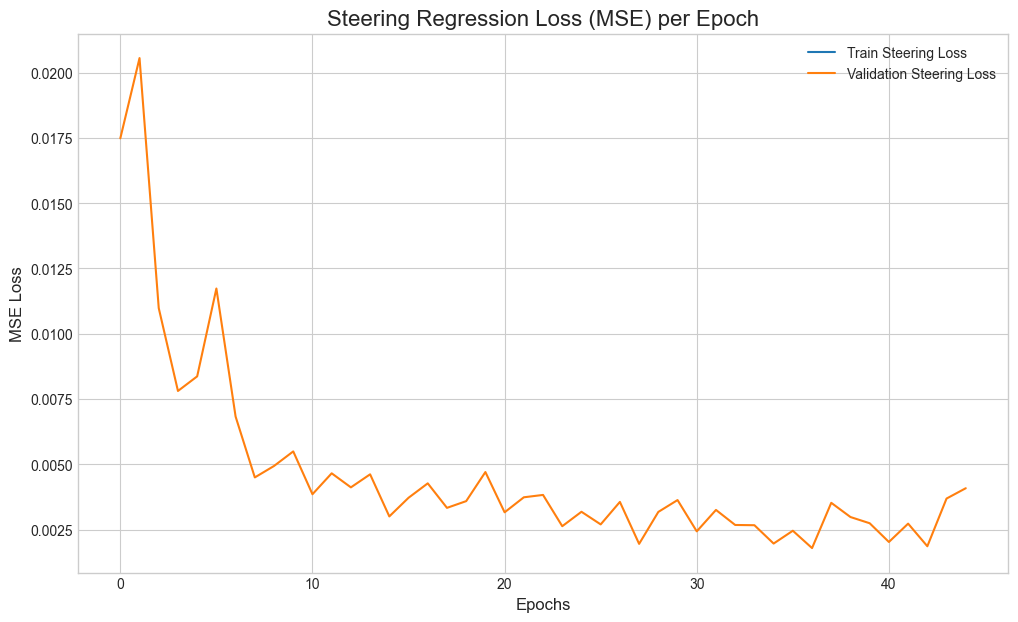

-> 조향값 손실 그래프가 'training_results\steering_loss_graph.png'에 저장되었습니다.


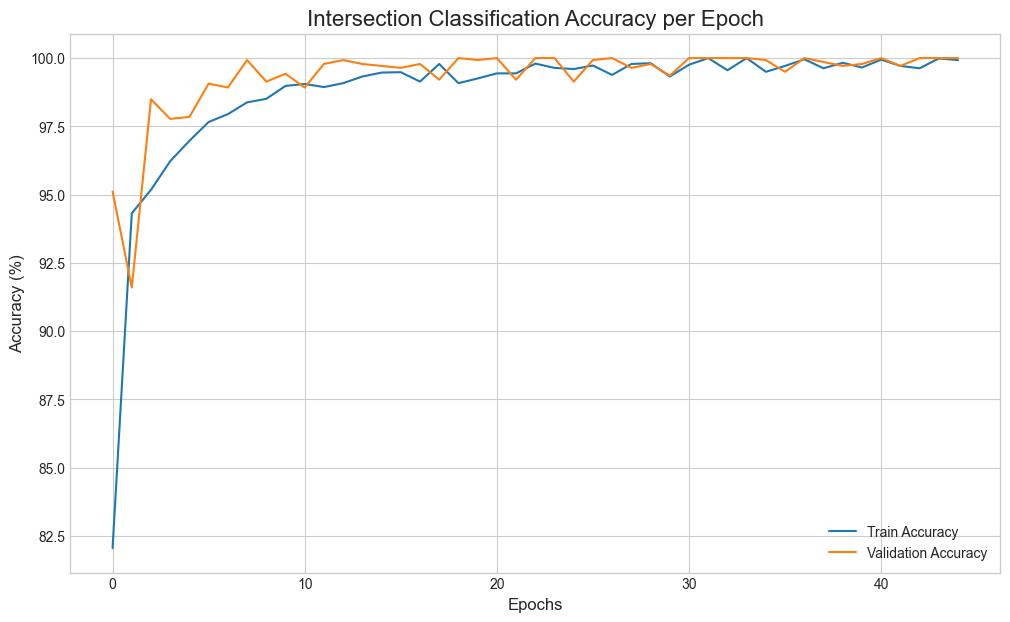

-> 정확도 그래프가 'training_results\accuracy_graph.png'에 저장되었습니다.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm # 진행 상황을 시각적으로 보여주는 라이브러리

# ==============================================================================
# --- 1. 주요 설정값 (Configuration) ---

# 데이터 처리 설정
GRAYSCALE = False  # True로 바꾸면 흑백으로, False면 컬러로 학습합니다.
ROI_CROP_HEIGHT = 130 # 이미지 하단에서부터 잘라낼 높이
IMAGE_SIZE = (224, 224) # 모델에 입력될 최종 이미지 크기

# 데이터셋 경로
DATA_PATH = 'split_dataset'

# 학습 하이퍼파라미터
BATCH_SIZE = 4   # 배치 사이즈 (메모리가 부족하면 8 또는 4로 줄이세요)
EPOCHS = 50       # 총 학습 에폭
LEARNING_RATE = 0.001 # 학습률
EARLY_STOPPING_PATIENCE = 8 # 성능 개선이 없을 때 몇 에폭을 더 기다릴지

# 모델 저장 경로
MODEL_SAVE_PATH = 'best_driving_model.pth'
# ==============================================================================


# --- 2. Custom Dataset 정의 ---
class DrivingDataset(Dataset):
    def __init__(self, data_dir, grayscale=False, roi_height=130, img_size=(224, 224)):
        self.data_dir = data_dir
        self.grayscale = grayscale
        self.roi_height = roi_height
        self.img_size = img_size
        self.image_files = [f for f in os.listdir(data_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.image_files[idx])

        # 1. 이미지 불러오기
        image = cv2.imread(img_path)
        if self.grayscale:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # PyTorch는 RGB 순서를 사용

        # 2. 관심 영역(ROI) 자르기
        height = image.shape[0]
        roi = image[height - self.roi_height:, :]

        # 3. 모델 입력 크기로 리사이즈
        resized_roi = cv2.resize(roi, self.img_size)

        # 4. 텐서로 변환 및 정규화
        if self.grayscale:
            # (H, W) -> (1, H, W)
            image_tensor = torch.from_numpy(resized_roi).float().unsqueeze(0)
        else:
            # (H, W, C) -> (C, H, W)
            image_tensor = torch.from_numpy(resized_roi).float().permute(2, 0, 1)

        image_tensor /= 255.0 # 0~1 사이로 정규화

        # 파일명에서 라벨 추출
        parts = self.image_files[idx].split('_')
        steering_label = float(parts[0]) / 150.0 - 1.0 # 조향값을 -1 ~ 1 범위로 정규화
        intersection_label = int(parts[1])

        return image_tensor, torch.tensor([steering_label], dtype=torch.float32), torch.tensor(intersection_label, dtype=torch.long)

# --- 3. 다중 출력(Multi-task) 전이학습 모델 정의 ---
class DrivingModel(nn.Module):
    def __init__(self, grayscale=False):
        super(DrivingModel, self).__init__()
        # MobileNetV2의 사전 훈련된 가중치 사용
        self.backbone = models.mobilenet_v2(weights='IMAGENET1K_V2')

        # 흑백 이미지 처리를 위해 첫 레이어 수정
        if grayscale:
            # 기존 첫 레이어의 가중치를 평균내어 1채널용 가중치로 만듦
            original_weights = self.backbone.features[0][0].weight.data
            new_weights = original_weights.mean(dim=1, keepdim=True)
            self.backbone.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            self.backbone.features[0][0].weight.data = new_weights

        # MobileNetV2의 마지막 분류 레이어의 입력 피처 수 가져오기
        num_features = self.backbone.classifier[1].in_features

        # 기존 분류기는 사용하지 않음
        self.backbone.classifier = nn.Identity()

        # 새로운 '헤드' 두 개를 정의
        # 1. 조향각 예측용 헤드 (Regression)
        self.steering_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1) # 최종 출력 1개 (조향값)
        )

        # 2. 교차로 종류 예측용 헤드 (Classification, 0~4까지 5개 클래스)
        self.intersection_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 5) # 최종 출력 5개 (클래스 0,1,2,3,4)
        )

    def forward(self, x):
        features = self.backbone(x)
        steering = self.steering_head(features)
        intersection = self.intersection_head(features)
        return steering, intersection

# --- 4. 훈련 및 검증 로직 ---
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 데이터셋 및 데이터로더 생성
train_dataset = DrivingDataset(os.path.join(DATA_PATH, 'train'), grayscale=GRAYSCALE, roi_height=ROI_CROP_HEIGHT, img_size=IMAGE_SIZE)
valid_dataset = DrivingDataset(os.path.join(DATA_PATH, 'valid'), grayscale=GRAYSCALE, roi_height=ROI_CROP_HEIGHT, img_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 모델, 손실 함수, 옵티마이저 정의
model = DrivingModel(grayscale=GRAYSCALE).to(device)
steering_loss_fn = nn.MSELoss() # 조향값은 회귀 문제이므로 MSE 사용
intersection_loss_fn = nn.CrossEntropyLoss() # 교차로는 분류 문제이므로 CrossEntropy 사용
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 학습 기록을 저장할 리스트
history = {
    'train_loss': [],
    'val_loss': [],
    'train_intersection_acc': [],
    'val_intersection_acc': [],
    'train_steering_loss': [],  # [추가] 훈련 조향값 손실 기록용
    'val_steering_loss': []     # [추가] 검증 조향값 손실 기록용
}

# 조기 종료 관련 변수
patience_counter = 0
best_val_loss = float('inf')

print("\n--- 훈련 시작 ---")
start_time = time.time()

for epoch in range(EPOCHS):
    # --- 훈련 단계 ---
    model.train()
    train_loss = 0.0
    correct_intersections = 0
    total_intersections = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, steer_labels, inter_labels in progress_bar:
        images, steer_labels, inter_labels = images.to(device), steer_labels.to(device), inter_labels.to(device)

        optimizer.zero_grad()

        steer_preds, inter_preds = model(images)

        loss_s = steering_loss_fn(steer_preds, steer_labels)
        loss_i = intersection_loss_fn(inter_preds, inter_labels)
        steering_loss_weight = 25.0  # 조향값 vs 교차로 예측의 배수
        total_loss = (steering_loss_weight * loss_s) + loss_i

        total_loss.backward()
        optimizer.step()

        train_loss += total_loss.item()

        _, predicted_inter = torch.max(inter_preds.data, 1)
        total_intersections += inter_labels.size(0)
        correct_intersections += (predicted_inter == inter_labels).sum().item()

        progress_bar.set_postfix(loss=total_loss.item())

    train_epoch_loss = train_loss / len(train_loader)
    train_epoch_acc = 100 * correct_intersections / total_intersections
    history['train_loss'].append(train_epoch_loss)
    history['train_intersection_acc'].append(train_epoch_acc)

    # --- 검증 단계 ---
    model.eval()
    val_loss = 0.0
    # [추가] 검증 단계의 조향값 손실을 따로 기록할 변수
    val_steering_loss = 0.0
    correct_intersections = 0
    total_intersections = 0

    with torch.no_grad():
        for images, steer_labels, inter_labels in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            images, steer_labels, inter_labels = images.to(device), steer_labels.to(device), inter_labels.to(device)

            steer_preds, inter_preds = model(images)

            loss_s = steering_loss_fn(steer_preds, steer_labels)
            loss_i = intersection_loss_fn(inter_preds, inter_labels)

            # [수정] 훈련 단계와 동일하게 가중치를 적용하여 전체 손실 계산
            # steering_loss_weight 변수는 훈련 루프 시작 전에 미리 정의되어 있어야 합니다. (예: steering_loss_weight = 10.0)
            total_loss = (steering_loss_weight * loss_s) + loss_i

            val_loss += total_loss.item()
            # [추가] 조향값 손실만 따로 누적
            val_steering_loss += loss_s.item()

            _, predicted_inter = torch.max(inter_preds.data, 1)
            total_intersections += inter_labels.size(0)
            correct_intersections += (predicted_inter == inter_labels).sum().item()


    # 각 에폭의 평균 손실 계산
    val_epoch_loss = val_loss / len(valid_loader)
    val_epoch_steering_loss = val_steering_loss / len(valid_loader) # [추가]
    val_epoch_acc = 100 * correct_intersections / total_intersections

    # 학습 기록(history)에 추가
    history['val_loss'].append(val_epoch_loss)
    history['val_steering_loss'].append(val_epoch_steering_loss) # [추가]
    history['val_intersection_acc'].append(val_epoch_acc)

    # 출력문에도 조향값 손실을 함께 표시하면 더 좋습니다.
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Steering Loss: {val_epoch_steering_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%")

    # --- 모델 저장 및 조기 종료 ---
    if val_epoch_loss < best_val_loss:
        print("  -> Validation loss decreased. Saving best model...")
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("--- 조기 종료 ---")
            break

end_time = time.time()
print(f"\n--- 훈련 종료 (총 소요 시간: {end_time - start_time:.2f}초) ---")


# --- 5. 결과 시각화 (그래프 생성 및 파일 저장) ---

# 결과를 저장할 폴더 생성
RESULTS_FOLDER = 'training_results'
os.makedirs(RESULTS_FOLDER, exist_ok=True)
print(f"\n훈련 결과 그래프를 '{RESULTS_FOLDER}' 폴더에 저장합니다...")

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

# --- 조향값 손실 그래프 ---
plt.figure(figsize=(12, 7)) # 새 그래프를 그릴 캔버스 생성
plt.plot(history['train_steering_loss'], label='Train Steering Loss')
plt.plot(history['val_steering_loss'], label='Validation Steering Loss')
plt.title('Steering Regression Loss (MSE) per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend()
plt.grid(True)

# [추가] 파일로 저장하는 코드
# plt.show()보다 먼저 호출해야 빈 이미지 저장을 방지할 수 있습니다.
steering_loss_graph_path = os.path.join(RESULTS_FOLDER, 'steering_loss_graph.png')
plt.savefig(steering_loss_graph_path, dpi=300) # dpi=300은 고해상도 저장 옵션

# 화면에 보여주기
plt.show()
print(f"-> 조향값 손실 그래프가 '{steering_loss_graph_path}'에 저장되었습니다.")


# --- 교차로 분류 정확도 그래프 ---
plt.figure(figsize=(12, 7)) # 또 다른 새 캔버스 생성
plt.plot(history['train_intersection_acc'], label='Train Accuracy')
plt.plot(history['val_intersection_acc'], label='Validation Accuracy')
plt.title('Intersection Classification Accuracy per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True)

# [추가] 파일로 저장하는 코드
accuracy_graph_path = os.path.join(RESULTS_FOLDER, 'accuracy_graph.png')
plt.savefig(accuracy_graph_path, dpi=300)

# 화면에 보여주기
plt.show()
print(f"-> 정확도 그래프가 '{accuracy_graph_path}'에 저장되었습니다.")


# 이미지 테스트 해보자

## 클래스 정의, 훈련 했으면 실행 안 해도 됨

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# --- [필수] 모델의 구조(설계도)를 정의하는 클래스 ---
# 이 클래스 정의가 있어야 .pth 가중치 파일을 불러와 모델을 재구성할 수 있습니다.
class DrivingModel(nn.Module):
    def __init__(self, grayscale=False):
        super(DrivingModel, self).__init__()
        # MobileNetV2의 사전 훈련된 가중치를 기본 뼈대로 사용
        self.backbone = models.mobilenet_v2(weights='IMAGENET1K_V2')

        # 만약 흑백(Grayscale)으로 훈련했다면, 모델의 첫 레이어를 1채널 입력에 맞게 수정
        if grayscale:
            # 기존 첫 레이어(3채널 입력)의 가중치를 평균내어 1채널용 가중치로 만듦
            original_weights = self.backbone.features[0][0].weight.data
            new_weights = original_weights.mean(dim=1, keepdim=True)
            self.backbone.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
            self.backbone.features[0][0].weight.data = new_weights

        # MobileNetV2의 마지막 분류 레이어의 입력 피처 수 가져오기
        num_features = self.backbone.classifier[1].in_features

        # 기존 분류기는 사용하지 않으므로 Identity로 대체 (그대로 통과시킴)
        self.backbone.classifier = nn.Identity()

        # 우리가 필요한 두 가지 출력을 위한 새로운 '헤드'를 정의
        # 1. 조향각 예측용 헤드 (Regression)
        self.steering_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1) # 최종 출력 1개 (조향값)
        )

        # 2. 교차로 종류 예측용 헤드 (Classification, 0~4까지 5개 클래스)
        self.intersection_head = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 5) # 최종 출력 5개 (클래스 0,1,2,3,4)
        )

    def forward(self, x):
        # 이미지를 백본에 통과시켜 핵심 특징 추출
        features = self.backbone(x)
        # 추출된 특징을 각 헤드에 통과시켜 두 가지 결과 동시 출력
        steering = self.steering_head(features)
        intersection = self.intersection_head(features)
        return steering, intersection

print("✅ DrivingModel 클래스가 성공적으로 정의되었습니다.")
print("이제 아래 '성능 시각화 테스트' 셀을 실행할 수 있습니다.")

✅ DrivingModel 클래스가 성공적으로 정의되었습니다.
이제 아래 '성능 시각화 테스트' 셀을 실행할 수 있습니다.


# 확인

In [ ]:
import os
import cv2
import numpy as np
import torch

# DrivingModel 클래스는 셀 1에서 이미 정의되었다고 가정합니다.

# --- 1. 설정값 ---
GRAYSCALE = False
ROI_CROP_HEIGHT = 130
IMAGE_SIZE = (224, 224)

TEST_DATA_DIR = os.path.join('split_dataset', 'test')
MODEL_PATH = 'best_driving_model.pth'

# 시각화 설정
Y_RATIO = 4 / 5
GT_DOT_COLOR = (255, 0, 0)      # 파란색: 정답 (Ground Truth)
PRED_DOT_COLOR = (0, 0, 255)    # 빨간색: 모델 예측 (Prediction)
LINE_COLOR = (0, 255, 0)
DOT_RADIUS = 7
# [수정] 기본 텍스트 색상을 흰색으로 변경
TEXT_COLOR = (255, 255, 255)
CORRECT_COLOR = (0, 255, 0)     # 초록색: 예측 성공
WRONG_COLOR = (0, 0, 255)       # 빨간색: 예측 실패

# --- 2. 모델 불러오기 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DrivingModel(grayscale=GRAYSCALE).to(device)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f"'{MODEL_PATH}' 모델을 성공적으로 불러왔습니다. 추론 디바이스: {device}")
    model_loaded = True
except FileNotFoundError:
    print(f"오류: '{MODEL_PATH}' 파일을 찾을 수 없습니다. 훈련을 먼저 완료해주세요.")
    model_loaded = False
except Exception as e:
    print(f"모델을 불러오는 중 오류 발생: {e}")
    model_loaded = False

# --- 3. 이미지 추론 및 시각화 ---
def run_inference_viewer_v2():
    try:
        image_files = [f for f in os.listdir(TEST_DATA_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        image_files.sort(key=lambda f: int(f.split('_')[0]))
        if not image_files:
            print(f"오류: '{TEST_DATA_DIR}' 폴더에 테스트 이미지가 없습니다.")
            return

        current_index = 0
        window_name = "Inference Viewer v2"

        print("\n--- 조작법 ---")
        print(" d : 다음 이미지 | a : 이전 이미지 | q : 종료")
        print("-------------------------------------------------")
        print(" 파란점: 정답 조향값 | 빨간점: AI 예측 조향값")
        print(" 초록색 텍스트: 교차로 예측 성공 | 빨간색 텍스트: 교차로 예측 실패")
        print("-------------------------------------------------")

        while True:
            filename = image_files[current_index]
            file_path = os.path.join(TEST_DATA_DIR, filename)
            display_image_orig = cv2.imread(file_path)
            if display_image_orig is None:
                current_index = (current_index + 1) % len(image_files)
                continue

            # 모델 입력을 위한 전처리 (생략)
            if GRAYSCALE:
                proc_image = cv2.cvtColor(display_image_orig, cv2.COLOR_BGR2GRAY)
            else:
                proc_image = cv2.cvtColor(display_image_orig, cv2.COLOR_BGR2RGB)
            height = proc_image.shape[0]
            roi = proc_image[height - ROI_CROP_HEIGHT:, :]
            resized_roi = cv2.resize(roi, IMAGE_SIZE)
            if GRAYSCALE:
                input_tensor = torch.from_numpy(resized_roi).float().unsqueeze(0).unsqueeze(0)
            else:
                input_tensor = torch.from_numpy(resized_roi).float().permute(2, 0, 1).unsqueeze(0)
            input_tensor = (input_tensor / 255.0).to(device)

            with torch.no_grad():
                steer_pred_norm, inter_pred_logits = model(input_tensor)

            predicted_steering = (steer_pred_norm.item() + 1.0) * 150.0
            predicted_steering = max(0, min(predicted_steering, 300))
            predicted_intersection = torch.max(inter_pred_logits.data, 1)[1].item()

            # 시각화
            display_image = display_image_orig.copy()
            disp_h, disp_w, _ = display_image.shape
            y_pos = int(disp_h * Y_RATIO)
            cv2.line(display_image, (0, y_pos), (disp_w, y_pos), LINE_COLOR, 1)

            gt_steering = int(filename.split('_')[0])
            gt_intersection = int(filename.split('_')[1])
            gt_x_pos = int((gt_steering / 300.0) * disp_w)
            cv2.circle(display_image, (gt_x_pos, y_pos), DOT_RADIUS, GT_DOT_COLOR, -1)

            pred_x_pos = int((predicted_steering / 300.0) * disp_w)
            cv2.circle(display_image, (pred_x_pos, y_pos), DOT_RADIUS, PRED_DOT_COLOR, -1)

            # [추가] 교차로 예측 결과에 따라 텍스트 색상 결정
            if gt_intersection == predicted_intersection:
                pred_text_color = CORRECT_COLOR # 정답일 경우 초록색
            else:
                pred_text_color = WRONG_COLOR   # 오답일 경우 빨간색

            # 텍스트 정보 표시
            gt_text =   f"Ground Truth: Steer={gt_steering}, Inter={gt_intersection}"
            pred_text = f"Prediction:   Steer={predicted_steering:.1f}, Inter={predicted_intersection}"

            # [수정] 정답(Ground Truth) 텍스트는 흰색으로, 예측(Prediction) 텍스트는 결과에 따른 색상으로 표시
            cv2.putText(display_image, gt_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, TEXT_COLOR, 2)
            cv2.putText(display_image, pred_text, (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, pred_text_color, 2)

            cv2.imshow(window_name, display_image)
            key = cv2.waitKey(0)

            if key == ord('d'):
                current_index = (current_index + 1) % len(image_files)
            elif key == ord('a'):
                current_index = (current_index - 1 + len(image_files)) % len(image_files)
            elif key == ord('q') or key == 27:
                break

        cv2.destroyAllWindows()
        for i in range(5): cv2.waitKey(1)
        print("\n테스트 뷰어를 종료합니다.")

    except Exception as e:
        cv2.destroyAllWindows()
        for i in range(5): cv2.waitKey(1)
        print(f"오류가 발생했습니다: {e}")

# --- 셀 실행 ---
if model_loaded:
    run_inference_viewer_v2()

C:\Users\user\AppData\Local\Temp\ipykernel_16176\3775103205.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=de

'best_driving_model.pth' 모델을 성공적으로 불러왔습니다. 추론 디바이스: cuda

--- 조작법 ---
 d : 다음 이미지 | a : 이전 이미지 | q : 종료
-------------------------------------------------
 파란점: 정답 조향값 | 빨간점: AI 예측 조향값
 초록색 텍스트: 교차로 예측 성공 | 빨간색 텍스트: 교차로 예측 실패
-------------------------------------------------

테스트 뷰어를 종료합니다.
